In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
data = pd.read_csv('data/crime_data_clean.csv')

data.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Latitude,Longitude,Location,Hour,Day_of_Week,Month,Is_Weekend,Season,Area_Hour_Crime_Count,Area_Season_Crime_Count
0,10365064,HZ100370,2015-12-31 23:59:00,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,41.757367,-87.642993,POINT (-87.642992854 41.757366519),23,3,12,0,Winter,351,1416
1,10364662,HZ100006,2015-12-31 23:55:00,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,...,41.751270,-87.585822,POINT (-87.585822373 41.751270452),23,3,12,0,Winter,53,303
2,10364740,HZ100010,2015-12-31 23:50:00,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,42.016804,-87.690709,POINT (-87.690708662 42.016804165),23,3,12,0,Winter,131,728
3,10364683,HZ100002,2015-12-31 23:50:00,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,...,41.949837,-87.658635,POINT (-87.658635101 41.949837364),23,3,12,0,Winter,255,1084
4,10366580,HZ102701,2015-12-31 23:45:00,050XX W CONCORD PL,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,41.910470,-87.751597,POINT (-87.751597381 41.910469677),23,3,12,0,Winter,767,3708


My initial guess is to start from the big picture, get a total understanding and then go down into meaningful details

In [104]:
stats_cols = ['Hour', 'Month', 'Area_Hour_Crime_Count', 'Area_Season_Crime_Count']
desc_stats = data[stats_cols].describe().T
desc_stats['variance'] = data[stats_cols].var()
print("--- Descriptive Statistics ---")
print(desc_stats[['mean', '50%', 'std', 'variance', '25%', '75%']])

--- Descriptive Statistics ---
                                mean     50%         std       variance  \
Hour                       13.301883    14.0    6.595156      43.496088   
Month                       6.593998     7.0    3.340280      11.157471   
Area_Hour_Crime_Count     276.764610   236.0  205.428550   42200.889070   
Area_Season_Crime_Count  1460.945875  1374.0  977.664621  955828.111168   

                           25%     75%  
Hour                       9.0    19.0  
Month                      4.0     9.0  
Area_Hour_Crime_Count    121.0   378.0  
Area_Season_Crime_Count  728.0  1981.0  


According to the output average crime time is at 13.3 o'clock with median 14, meaning mathematical center of crime activity is 2 o'clock in the afternoon. According to what has been stated before, most of the crime time tends to happen in the middle of the day.  

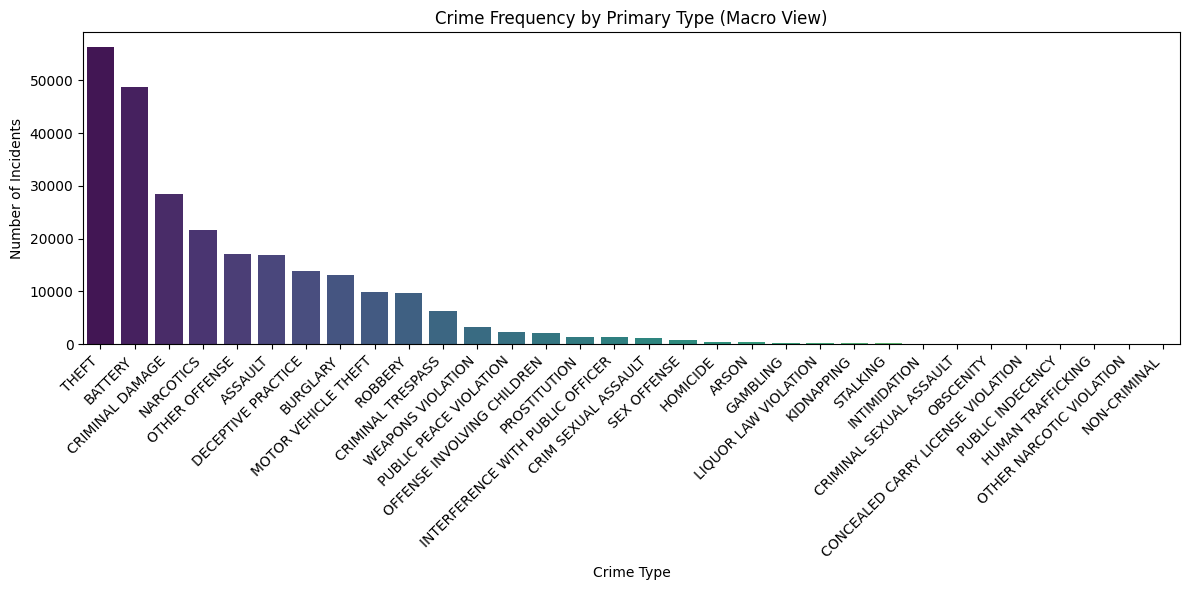

In [105]:
plt.figure(figsize=(12, 6))
crime_counts = data['Primary Type'].value_counts()

sns.barplot(
    x=crime_counts.index,
    y=crime_counts.values,
    hue=crime_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Crime Frequency by Primary Type (Macro View)')
plt.xlabel('Crime Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


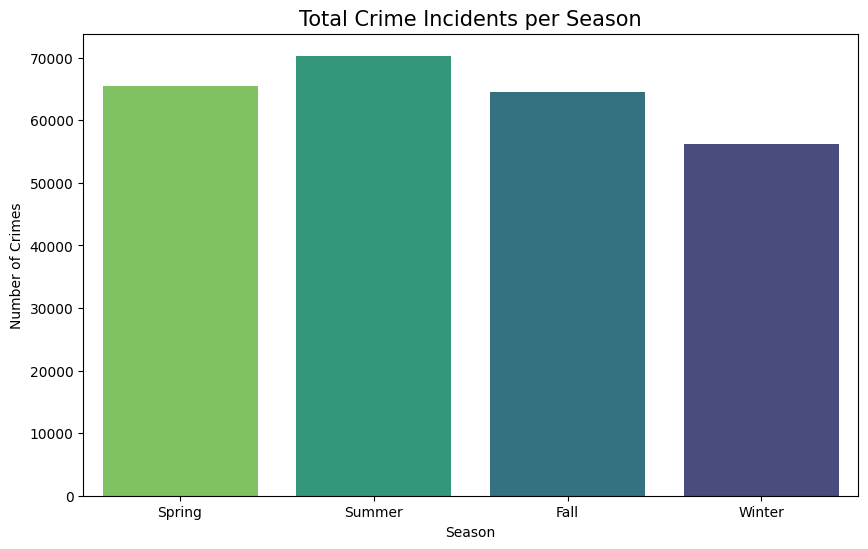

In [106]:
seasonal_order = ['Spring', 'Summer', 'Fall', 'Winter']

plt.figure(figsize=(10, 6))
sns.countplot(
    data=data,
    x='Season',
    order=seasonal_order,
    hue='Season',
    palette='viridis',
    legend=False
)

plt.title('Total Crime Incidents per Season', fontsize=15)
plt.ylabel('Number of Crimes')
plt.show()


According to this plot, we have a bell curve type plot, we see the most crimes happen in summer, while the least in winter.

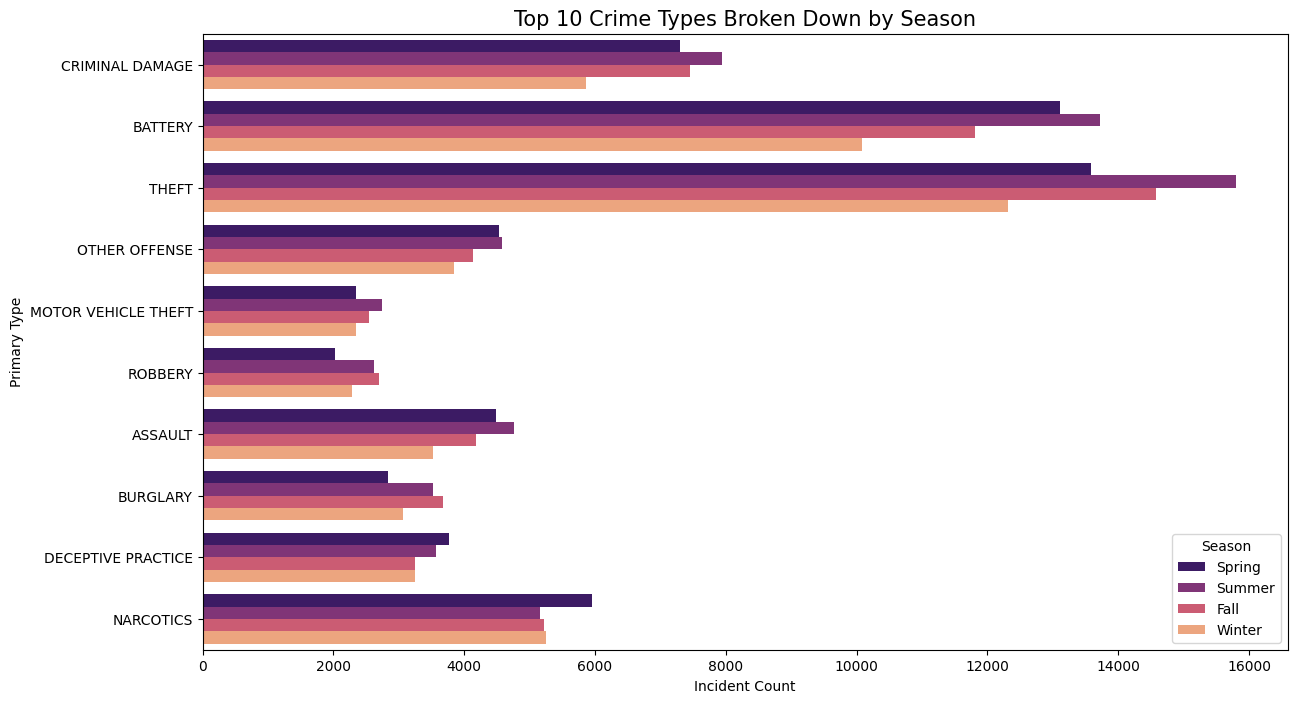

In [107]:
top_10_crimes = data['Primary Type'].value_counts().nlargest(10).index
data_top10 = data[data['Primary Type'].isin(top_10_crimes)]

plt.figure(figsize=(14, 8))
sns.countplot(data=data_top10, y='Primary Type', hue='Season',
              hue_order=seasonal_order, palette='magma')
plt.title('Top 10 Crime Types Broken Down by Season', fontsize=15)
plt.xlabel('Incident Count')
plt.legend(title='Season', loc='lower right')
plt.show()

Most of the crimes mostly happen in summer, but some crimes still ruin this trend, most of which stay stable throughout the year, but there is an outlier, Narcotics to be more precise, which dominates by ~1000, which could point at something meaningful. We can see theft is overall most dominant crime. More stable crimes are deceptive practice, which is mostly carried out online, so cannot be affected by seasons.

My next thought is to try to find why these criminal activities depend on seasons, maybe holiday periods, or daylight hours.   

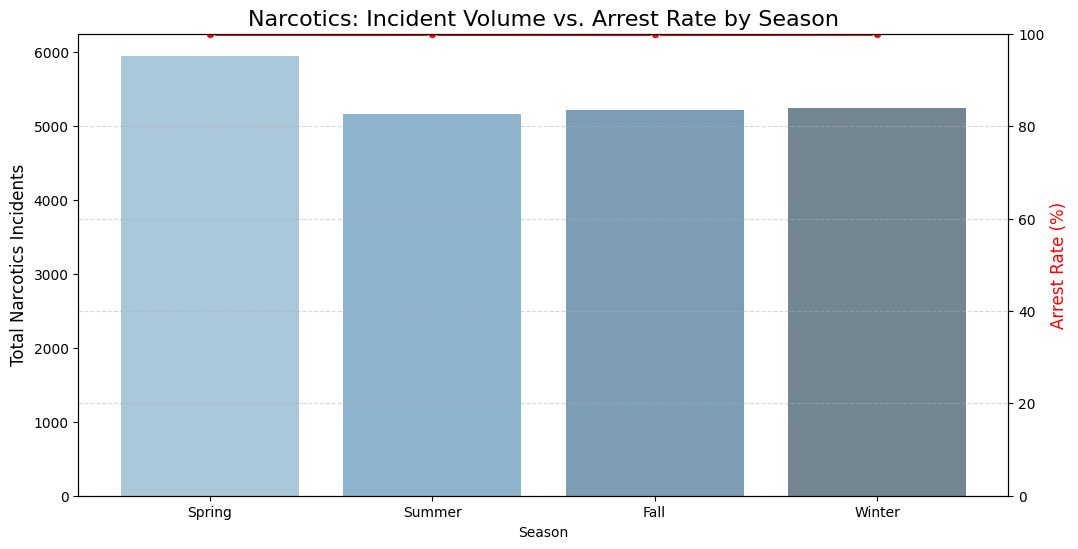

--- Narcotics Seasonal Metrics ---
Arrest  Total  Arrest Rate (%)
Season                        
Spring   5949        99.966381
Summer   5165        99.961278
Fall     5219        99.942518
Winter   5244        99.980931


In [108]:
narcotics_data = data[data['Primary Type'] == 'NARCOTICS']

arrest_counts = (
    narcotics_data
    .groupby(['Season', 'Arrest'])
    .size()
    .unstack(fill_value=0)
)

arrest_counts['Total'] = arrest_counts[True] + arrest_counts[False]
arrest_counts['Arrest Rate (%)'] = (
    arrest_counts[True] / arrest_counts['Total']
) * 100

seasons_order = ['Spring', 'Summer', 'Fall', 'Winter']
arrest_counts = arrest_counts.reindex(seasons_order)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=arrest_counts.index,
    y=arrest_counts['Total'],
    hue=arrest_counts.index,
    palette='Blues_d',
    legend=False,
    alpha=0.7,
    ax=ax1
)

ax1.set_ylabel('Total Narcotics Incidents', fontsize=12)
ax1.set_title('Narcotics: Incident Volume vs. Arrest Rate by Season', fontsize=16)

ax2 = ax1.twinx()
sns.lineplot(
    x=arrest_counts.index,
    y=arrest_counts['Arrest Rate (%)'],
    ax=ax2,
    color='red',
    marker='o',
    linewidth=3
)

ax2.set_ylabel('Arrest Rate (%)', color='red', fontsize=12)
ax2.set_ylim(0, 100)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("--- Narcotics Seasonal Metrics ---")
print(arrest_counts[['Total', 'Arrest Rate (%)']])


There is a really interesting part to think about here, when it comes to narcotics, legally there is no victim, the crime only "happened" according to our data, because the police found them, which is backed by this results

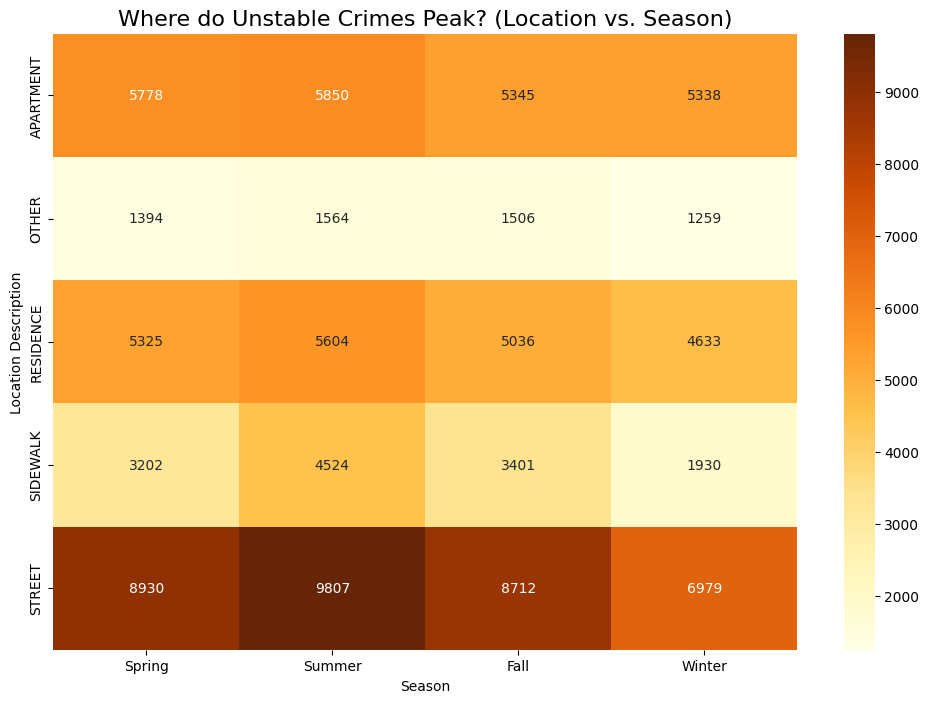

In [109]:
unstable_crimes = ['BATTERY', 'THEFT', 'ASSAULT', 'CRIMINAL DAMAGE']
data_unstable = data[data['Primary Type'].isin(unstable_crimes)]

top_locations = data_unstable['Location Description'].value_counts().nlargest(5).index
df_loc = data_unstable[data_unstable['Location Description'].isin(top_locations)]

loc_pivot = pd.crosstab(df_loc['Location Description'], df_loc['Season'])[['Spring', 'Summer', 'Fall', 'Winter']]

plt.figure(figsize=(12, 8))
sns.heatmap(loc_pivot, annot=True, fmt="d", cmap="YlOrBr")
plt.title('Where do Unstable Crimes Peak? (Location vs. Season)', fontsize=16)
plt.show()

Based on the matrix given above, the huge increase in street crimes from winter to summer, could suggest that warmer weather or day time increasing could be the driven factor for crimes in summer.   

Crimes that happened in the apartments stay relatively stable, with only small falctuation.  

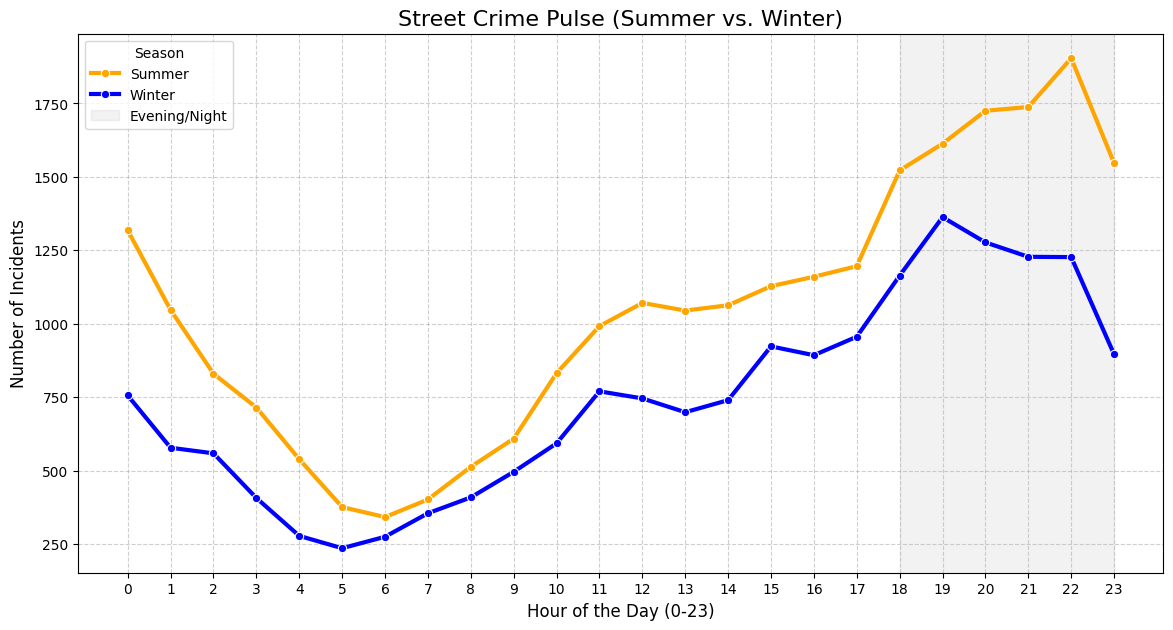

In [113]:
outdoor_locations = ['STREET', 'SIDEWALK']
data_street = data[data['Location Description'].isin(outdoor_locations)]

data_compare = data_street[data_street['Season'].isin(['Summer', 'Winter'])]

hourly_pulse = data_compare.groupby(['Hour', 'Season']).size().reset_index(name='Crime Count')

plt.figure(figsize=(14, 7))
sns.lineplot(data=hourly_pulse, x='Hour', y='Crime Count', hue='Season',
             palette={'Summer': 'orange', 'Winter': 'blue'}, linewidth=3, marker='o')

plt.title('Street Crime Pulse (Summer vs. Winter)', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvspan(18, 23, color='gray', alpha=0.1, label='Evening/Night')

plt.legend(title='Season')
plt.show()

This observation gave us nothing, as both lines are highly correlated.

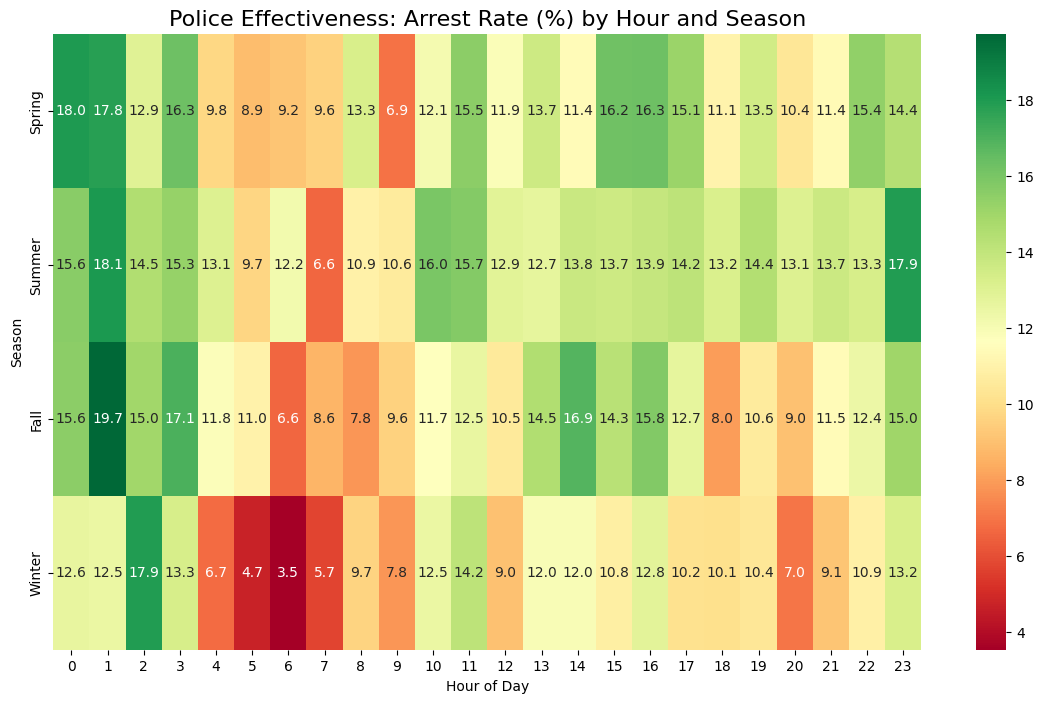

In [111]:
unstable_street = data[(data['Primary Type'].isin(['BATTERY', 'ASSAULT', 'THEFT'])) &
                       (data['Location Description'].isin(['STREET', 'SIDEWALK']))]

arrest_pivot = unstable_street.groupby(['Hour', 'Season'])['Arrest'].mean().unstack() * 100
arrest_pivot = arrest_pivot[['Spring', 'Summer', 'Fall', 'Winter']]

plt.figure(figsize=(14, 8))
sns.heatmap(arrest_pivot.T, cmap='RdYlGn', annot=True, fmt=".1f")
plt.title('Police Effectiveness: Arrest Rate (%) by Hour and Season', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Season')
plt.show()

 The heatmap shows more Red in Winter, meaning that even though fewer crimes happen, the police catch a smaller percentage of those criminals compared to the Summer. This could suggest that bad weather and darkness make it easier for criminals to get away.

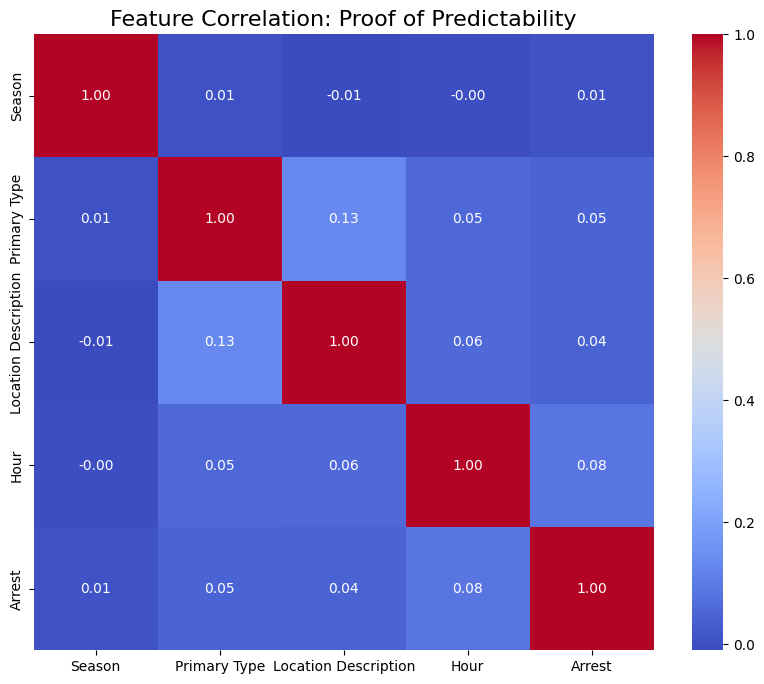

In [112]:
data_numeric = data[['Season', 'Primary Type', 'Location Description', 'Hour', 'Arrest']].copy()
for col in ['Season', 'Primary Type', 'Location Description']:
    data_numeric[col] = data_numeric[col].astype('category').cat.codes

corr = data_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation: Proof of Predictability', fontsize=16)
plt.show()

After spending time with the data, the short answer is yes — there is structure here. Crime in the city doesn’t behave like pure randomness. It moves with a fairly stable rhythm.

The strongest pattern that shows up is the time–location signal. Regardless of season, the city follows the same daily routine: people wake up, commute, and return home at roughly the same hours, and crime tracks those movements closely. These daily cycles are remarkably consistent, which suggests that a model wouldn’t need to infer complex behavior — a large part of the signal is already embedded in the clock.

Weather and seasonality behave more like a volume control than a structural change. Warmer months don’t fundamentally alter how crime happens, but they reliably increase how much of it occurs, especially in street-level locations. Apartments, by contrast, remain relatively stable across seasons. This creates a simple but meaningful rule: season amplifies risk in certain contexts without reshaping the underlying pattern.

Looking at arrest patterns reinforces the same idea. Areas with low arrest rates during summer nights don’t appear random; they align with predictable spikes in crime volume, suggesting capacity limits rather than enforcement failure. The system strains in consistent places and times.

Taken together, this analysis helps separate signal from noise. For example, narcotics data appears to reflect policing schedules more than underlying criminal behavior, making it a poor target for prediction in this context. Removing that clears the picture considerably.

What remains is a dataset that reflects stable, repeatable aspects of human behavior. From an exploratory standpoint, the data shows enough structure to justify modeling, and it gives clear guidance on where prediction is likely to work — and where it probably won’t.